In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

os.chdir(os.path.dirname(os.path.abspath("__file__")) + "/..")
print("Working directory:", os.getcwd())

Working directory: C:\Users\user\Desktop\risk_dashboard


In [2]:
returns = pd.read_csv("data/processed/returns_clean.csv",
                       index_col="Date", parse_dates=True)
print("Returns shape:", returns.shape)
returns.head()

Returns shape: (752, 15)


,AAPL,CVX,EL,GS,HLI,JNJ,JPM,KO,MCD,META,MRK,PLTR,ULTA,UNH,XOM
Date,,,,,,,,,,,,,,,
2022-01-04,-0.012773,0.018032,0.004231,0.030271,0.044539,-0.002685,0.037209,0.016557,-0.000261,-0.005955,0.001819,-0.019619,0.013246,-0.022917,0.036924
2022-01-05,-0.026960,0.006485,-0.043278,-0.021958,-0.040624,0.006642,-0.018451,0.008259,-0.004928,-0.037419,0.023992,-0.068914,-0.042068,-0.002468,0.012361
2022-01-06,-0.016834,0.008473,-0.002024,-0.004274,0.048372,-0.003432,0.010568,-0.005278,0.009313,0.025251,-0.000634,-0.013057,-0.002494,-0.041785,0.023248
2022-01-07,0.000988,0.014258,-0.001295,0.001460,0.010838,0.013427,0.009860,-0.002318,-0.009800,-0.002017,0.018476,-0.010811,-0.008501,-0.023810,0.008163
2022-01-10,0.000116,0.000640,-0.055137,0.004167,0.036082,-0.004956,0.000957,0.001656,-0.009973,-0.011275,0.025452,-0.003630,-0.041284,0.013859,-0.005970


In [3]:
def parametric_var(returns, confidence=0.95):
    """
    Parametric VaR using normal distribution
    Formula: VaR = mean - z_score * std_dev
    """
    var_results = {}
    z_score = norm.ppf(1 - confidence)
    
    for ticker in returns.columns:
        r = returns[ticker].dropna()
        mean = r.mean()
        std = r.std()
        var = mean + z_score * std
        var_results[ticker] = round(var, 4)
    
    return var_results

In [4]:
var_95 = parametric_var(returns, confidence=0.95)
var_99 = parametric_var(returns, confidence=0.99)

var_df = pd.DataFrame({
    "VaR_95%": var_95,
    "VaR_99%": var_99
})

# Add risk level
def risk_level(var):
    if var < -0.05:
        return "🔴 Very High Risk"
    elif var < -0.03:
        return "🟠 High Risk"
    elif var < -0.02:
        return "🟡 Medium Risk"
    else:
        return "🟢 Low Risk"

var_df["Risk Level"] = var_df["VaR_95%"].apply(risk_level)
var_df["Max Loss 95% (%)"] = (var_df["VaR_95%"] * 100).round(2).astype(str) + "%"
var_df["Max Loss 99% (%)"] = (var_df["VaR_99%"] * 100).round(2).astype(str) + "%"
var_df = var_df.sort_values("VaR_95%")

print("=" * 60)
print("   PARAMETRIC VAR RESULTS - RISK RANKING")
print("=" * 60)
print(var_df[["Max Loss 95% (%)", "Max Loss 99% (%)", "Risk Level"]])
print("=" * 60)
print(f"Most Risky Stock:  {var_df.index[0]}  {var_df['Max Loss 95% (%)'].iloc[0]}")
print(f"Safest Stock:      {var_df.index[-1]}  {var_df['Max Loss 95% (%)'].iloc[-1]}")

   PARAMETRIC VAR RESULTS - RISK RANKING
     Max Loss 95% (%) Max Loss 99% (%)        Risk Level
PLTR           -6.85%           -9.77%  🔴 Very High Risk
META           -5.05%           -7.17%  🔴 Very High Risk
EL             -4.68%           -6.53%       🟠 High Risk
ULTA           -3.45%           -4.88%       🟠 High Risk
AAPL           -2.76%           -3.92%     🟡 Medium Risk
HLI            -2.75%           -3.93%     🟡 Medium Risk
XOM            -2.74%           -3.91%     🟡 Medium Risk
GS             -2.68%           -3.81%     🟡 Medium Risk
CVX            -2.63%           -3.74%     🟡 Medium Risk
UNH            -2.53%           -3.58%     🟡 Medium Risk
JPM            -2.52%           -3.59%     🟡 Medium Risk
MRK            -2.04%            -2.9%     🟡 Medium Risk
MCD            -1.78%           -2.53%        🟢 Low Risk
JNJ             -1.7%           -2.41%        🟢 Low Risk
KO              -1.6%           -2.28%        🟢 Low Risk
Most Risky Stock:  PLTR  -6.85%
Safest Stock:  

In [5]:
var_df.to_csv("data/processed/parametric_var.csv")
print("Saved to data/processed/parametric_var.csv")

Saved to data/processed/parametric_var.csv


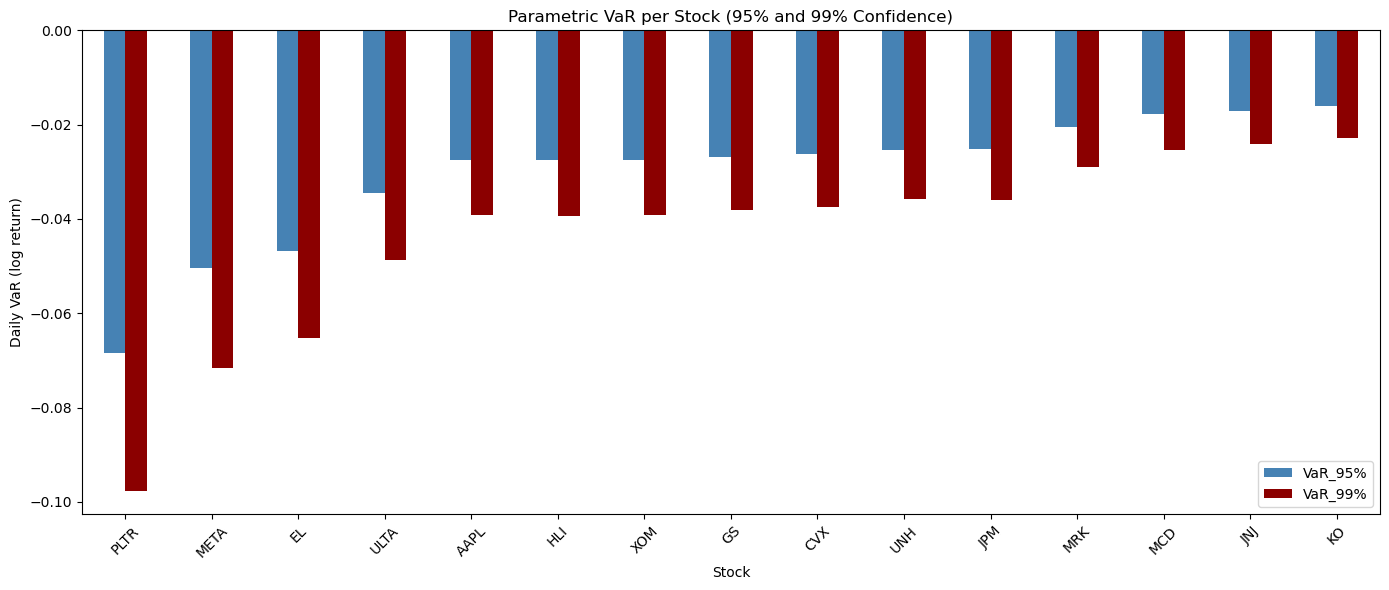

Chart saved!


In [6]:
var_df[["VaR_95%", "VaR_99%"]].plot(
    kind="bar",
    figsize=(14, 6),
    color=["steelblue", "darkred"],
    title="Parametric VaR per Stock (95% and 99% Confidence)"
)
plt.ylabel("Daily VaR (log return)")
plt.xlabel("Stock")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("reports/parametric_var_chart.png")
plt.show()
print("Chart saved!")